# Step 8. Regime-Aware Covariance Module

**목적**: Walk-Forward 31개 윈도우 각각에 대해 **Σ_stable / Σ_crisis를 IS 데이터 + Full-sample HMM 레짐 라벨로 분리 추정**하여 Step9 통합 백테스트의 입력으로 활용합니다.

**핵심 설계** (decision_log_v31 참조):
- HMM 레짐 라벨은 Step6의 **Full-sample 학습 결과** 고정 사용 (Deployment Simulation 철학)
- 레짐 4단계를 VIX 평균 기준 **Stable {0,1} / Crisis {2,3} 2그룹**으로 자동 분류
- 각 WF 윈도우에서 IS 데이터만 사용하여 μ, Σ_stable, Σ_crisis 추정
- **3단계 Fallback 로직**: 관측수에 따라 separate / scaled / single 동적 선택

**목차**:
- 8-1. Full-sample HMM 레짐 검증 및 자동 그룹화
- 8-2. Walk-Forward 윈도우 생성
- 8-3. Σ 추정 + 3단계 Fallback 로직
- 8-4. 결과 검증 및 시각화
- 8-5. (확장) 4개 Σ 별도 추정 버전
- 8-6. 산출물 저장

**입력 파일**:
- `data/portfolio_prices.csv` (Step1)
- `data/regime_history.csv` (Step6, Full-sample HMM 산출물)

**산출물**:
- `data/regime_covariance_by_window.pkl` — 32 윈도우의 {μ, Σ_stable, Σ_crisis, fallback_type}
- `data/regime_covariance_4group.pkl` — 4개 Σ 버전 (확장 실험용)
- `images/step8_*.png` — 4개 시각화


In [1]:
# ============================================================
# 라이브러리 임포트 + 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import platform
import warnings
from pathlib import Path

from sklearn.covariance import LedoitWolf

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (CLAUDE.md 지침 준수)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa: F401
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 120

# 경로 설정
DATA_DIR = Path('data')
IMG_DIR = Path('images')
DATA_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

print('라이브러리 임포트 완료')
print(f'  OS: {platform.system()}')
print(f'  Data dir: {DATA_DIR.resolve()}')
print(f'  Image dir: {IMG_DIR.resolve()}')


라이브러리 임포트 완료
  OS: Windows
  Data dir: C:\Users\gorhk\최종 프로젝트\finance_project\김재천\Guide\data
  Image dir: C:\Users\gorhk\최종 프로젝트\finance_project\김재천\Guide\images


In [2]:
# ============================================================
# 데이터 로드
# ============================================================

# 30개 포트폴리오 자산의 일별 가격
prices = pd.read_csv(DATA_DIR / 'portfolio_prices.csv',
                     parse_dates=['Date'], index_col='Date')

# Step6에서 생성된 Full-sample HMM 레짐 라벨
regime_df = pd.read_csv(DATA_DIR / 'regime_history.csv',
                         parse_dates=['Date'], index_col='Date')

# 일별 로그 수익률 (시간 합산성 있음, 정규성 가까움)
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns = log_returns.loc['2016-01-01':]  # ANALYSIS_START 슬라이싱 (2026-04-19)

# 30개 자산 이름
PORT_TICKERS = list(prices.columns)

print(f'포트폴리오 자산 수: {len(PORT_TICKERS)}개')
print(f'가격 데이터: {prices.shape[0]}일 ({prices.index[0].date()} ~ {prices.index[-1].date()})')
print(f'로그 수익률: {log_returns.shape[0]}일')
print(f'레짐 데이터: {regime_df.shape[0]}일')
print(f'레짐 컬럼: {list(regime_df.columns)}')


포트폴리오 자산 수: 30개
가격 데이터: 3017일 (2014-01-02 ~ 2025-12-30)
로그 수익률: 2513일
레짐 데이터: 2491일
레짐 컬럼: ['hmm_regime', 'VIX_level', 'VIX_contango', 'HY_spread', 'yield_curve', 'Cu_Au_ratio_chg', 'rv_neutral']


## 8-1. Full-sample HMM 레짐 검증 및 자동 그룹화

Step6에서 Full-sample로 학습된 HMM이 부여한 4개 레짐 라벨을 검증하고, **VIX 평균 기준으로 Stable/Crisis 2그룹**으로 자동 분류합니다.

**자동 분류 이유**: HMM의 레짐 번호(0, 1, 2, 3)는 **임의적(arbitrary)**. 번호 자체에 의미가 없으므로, 각 레짐의 **VIX 평균**을 기준으로 정렬하여 하위 2개 → Stable, 상위 2개 → Crisis로 할당합니다.

**분류 근거의 이중 검증**: VIX 평균만으로 Stable/Crisis를 나눌 경우 경계에 있는 레짐(VIX 19.19 vs 19.93)의 구분이 미묘할 수 있습니다. 그러나 **HY_spread(신용 스프레드)** 도 함께 확인하면 분류가 견고해집니다:
- 레짐 1 (Stable): HY 3.17% (건전한 신용환경)
- 레짐 2 (Crisis): HY 4.34% (신용 긴장)

VIX + HY_spread **이중 지표**가 동일한 그룹화를 지지하므로 분류는 신뢰할 수 있습니다.


In [3]:
# ============================================================
# 4개 레짐의 특성 분석 (Full-sample 기준)
# ============================================================

# 각 레짐의 VIX, HY_spread 평균 (레짐 특성 파악용)
regime_profile = regime_df.groupby('hmm_regime').agg({
    'VIX_level':    'mean',
    'HY_spread':    'mean',
    'yield_curve':  'mean',
    'Cu_Au_ratio_chg': 'mean',
}).round(3)

# 각 레짐의 영업일 수 추가
regime_profile['영업일수'] = regime_df['hmm_regime'].value_counts().sort_index()
regime_profile['비중(%)'] = (regime_profile['영업일수'] / len(regime_df) * 100).round(1)

# VIX 기준 오름차순 정렬 → 저변동 레짐부터
regime_profile_sorted = regime_profile.sort_values('VIX_level')

# 해석 태그 추가
def interpret_regime(vix):
    if vix < 16: return '저변동'
    elif vix < 21: return '일반'
    elif vix < 28: return '고변동'
    else: return '위기'

regime_profile_sorted['해석'] = regime_profile_sorted['VIX_level'].apply(interpret_regime)

print('=' * 75)
print('HMM 4개 레짐 특성 요약 (VIX 평균 기준 정렬)')
print('=' * 75)
print(regime_profile_sorted[['VIX_level', 'HY_spread', '영업일수', '비중(%)', '해석']])


HMM 4개 레짐 특성 요약 (VIX 평균 기준 정렬)
            VIX_level  HY_spread  영업일수  비중(%)   해석
hmm_regime                                        
0              14.868      2.031   544   21.8  저변동
1              17.990      1.791   689   27.7   일반
2              18.487      2.009   830   33.3   일반
3              23.129      2.834   428   17.2  고변동


In [4]:
# ============================================================
# VIX 평균 기준 Stable / Crisis 그룹 자동 결정
# ============================================================

# VIX 평균 오름차순 정렬
regime_vix_means = regime_df.groupby('hmm_regime')['VIX_level'].mean().sort_values()

# 하위 2개 → Stable, 상위 2개 → Crisis
STABLE_REGIMES = regime_vix_means.index[:2].tolist()
CRISIS_REGIMES = regime_vix_means.index[2:].tolist()

print('=' * 60)
print('Stable / Crisis 자동 그룹화 결과')
print('=' * 60)
print(f'Stable 그룹 (낮은 VIX): 레짐 {STABLE_REGIMES}')
for r in STABLE_REGIMES:
    print(f'  레짐 {int(r)}: VIX 평균 {regime_vix_means[r]:.2f}')
print(f'Crisis 그룹 (높은 VIX): 레짐 {CRISIS_REGIMES}')
for r in CRISIS_REGIMES:
    print(f'  레짐 {int(r)}: VIX 평균 {regime_vix_means[r]:.2f}')

# Stable / Crisis 라벨 컬럼 추가 (편의용)
regime_df['regime_group'] = regime_df['hmm_regime'].apply(
    lambda r: 'stable' if r in STABLE_REGIMES else 'crisis'
)

stable_count = (regime_df['regime_group'] == 'stable').sum()
crisis_count = (regime_df['regime_group'] == 'crisis').sum()
print()
print(f'Full-sample 분포:')
print(f'  Stable: {stable_count}일 ({stable_count/len(regime_df)*100:.1f}%)')
print(f'  Crisis: {crisis_count}일 ({crisis_count/len(regime_df)*100:.1f}%)')


Stable / Crisis 자동 그룹화 결과
Stable 그룹 (낮은 VIX): 레짐 [0, 1]
  레짐 0: VIX 평균 14.87
  레짐 1: VIX 평균 17.99
Crisis 그룹 (높은 VIX): 레짐 [2, 3]
  레짐 2: VIX 평균 18.49
  레짐 3: VIX 평균 23.13

Full-sample 분포:
  Stable: 1233일 (49.5%)
  Crisis: 1258일 (50.5%)


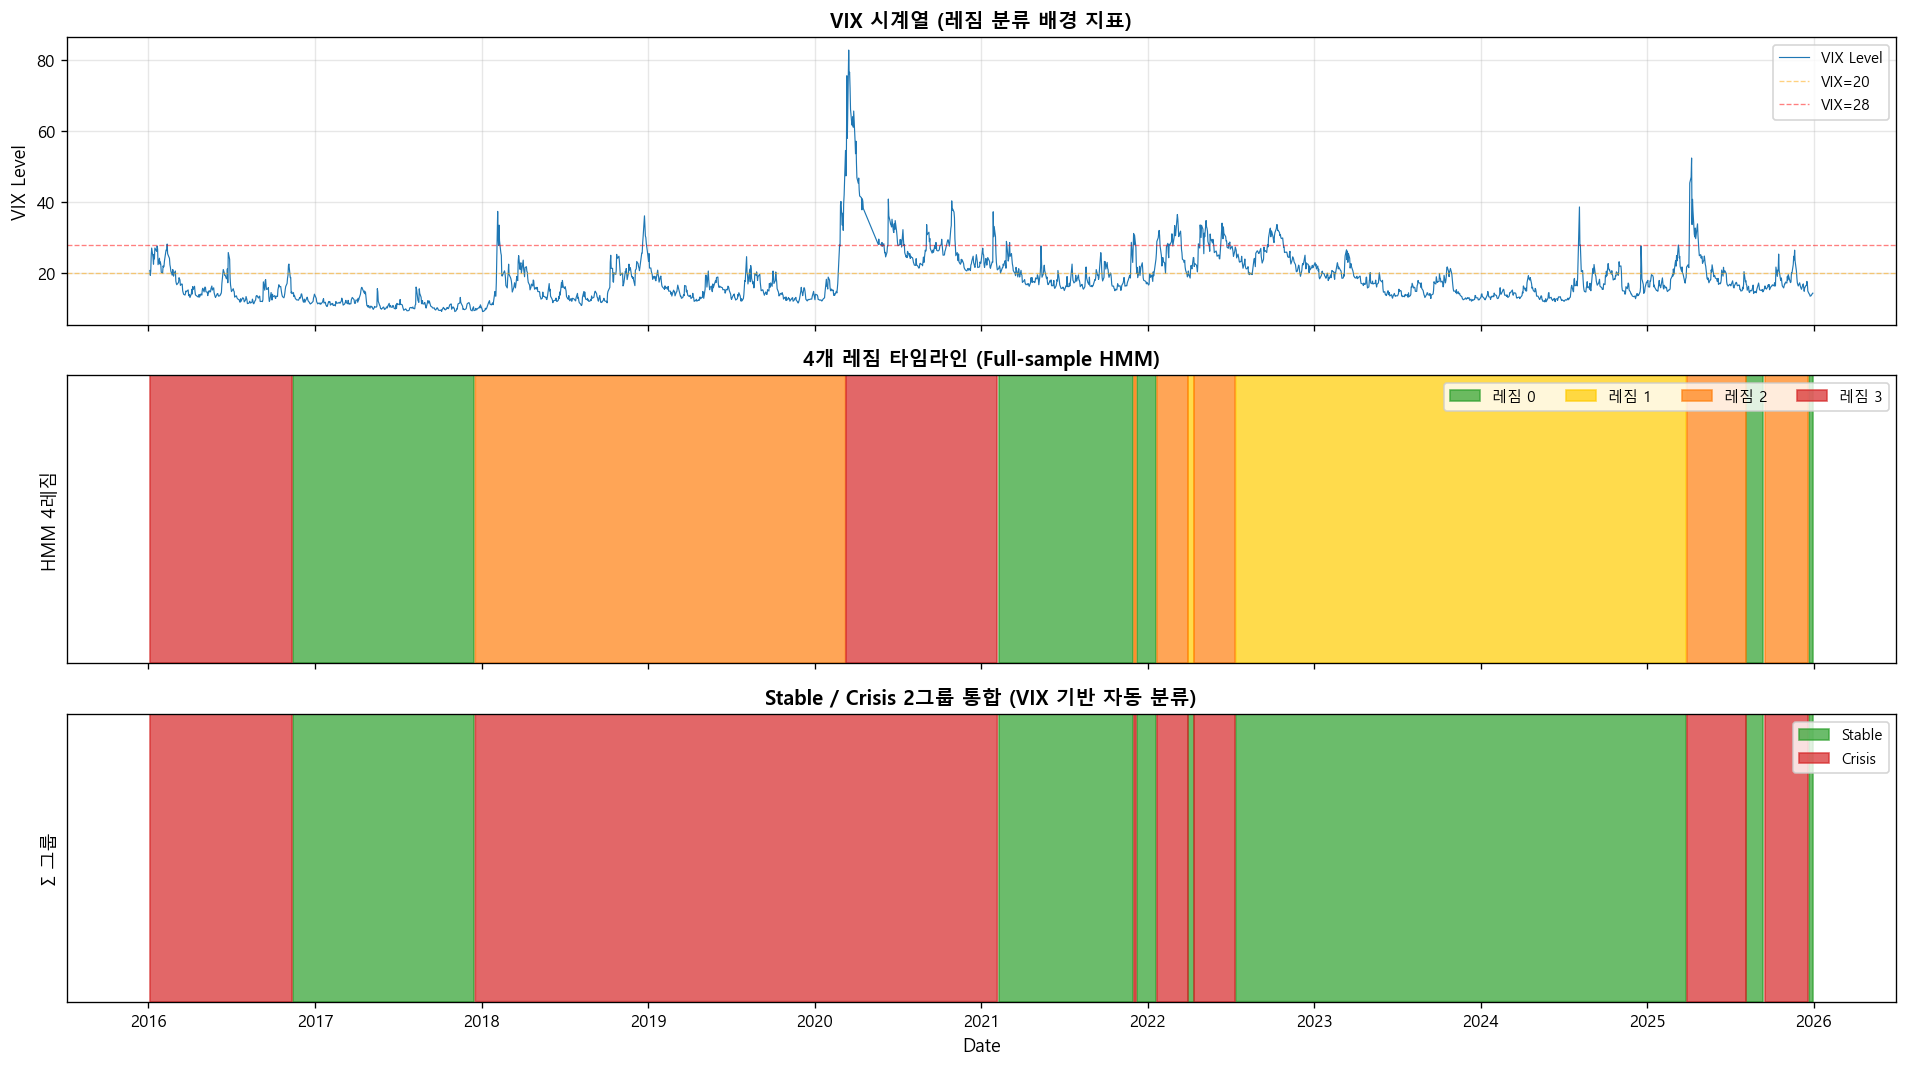

저장: images/step8_01_regime_timeline.png


In [5]:
# ============================================================
# 시각화: 레짐 타임라인 (10년 전체)
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# ---- 상단: VIX와 레짐 오버레이 ----
ax1 = axes[0]
ax1.plot(regime_df.index, regime_df['VIX_level'],
         color='#1f77b4', linewidth=0.7, label='VIX Level')
ax1.axhline(20, color='orange', linestyle='--', alpha=0.5, linewidth=0.8, label='VIX=20')
ax1.axhline(28, color='red', linestyle='--', alpha=0.5, linewidth=0.8, label='VIX=28')
ax1.set_ylabel('VIX Level', fontsize=11)
ax1.set_title('VIX 시계열 (레짐 분류 배경 지표)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)

# ---- 중단: 4개 레짐 타임라인 ----
ax2 = axes[1]
regime_colors = {0: '#2ca02c', 1: '#ffcc00', 2: '#ff7f0e', 3: '#d62728'}
for r in sorted(regime_df['hmm_regime'].unique()):
    mask = regime_df['hmm_regime'] == r
    ax2.fill_between(regime_df.index, 0, 1, where=mask,
                     color=regime_colors.get(int(r), 'gray'),
                     alpha=0.7, label=f'레짐 {int(r)}',
                     transform=ax2.get_xaxis_transform())
ax2.set_ylabel('HMM 4레짐', fontsize=11)
ax2.set_title('4개 레짐 타임라인 (Full-sample HMM)', fontsize=12, fontweight='bold')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=9, ncol=4)

# ---- 하단: Stable / Crisis 이분법 타임라인 ----
ax3 = axes[2]
group_colors = {'stable': '#2ca02c', 'crisis': '#d62728'}
for group in ['stable', 'crisis']:
    mask = regime_df['regime_group'] == group
    ax3.fill_between(regime_df.index, 0, 1, where=mask,
                     color=group_colors[group], alpha=0.7,
                     label=group.capitalize(),
                     transform=ax3.get_xaxis_transform())
ax3.set_ylabel('Σ 그룹', fontsize=11)
ax3.set_title('Stable / Crisis 2그룹 통합 (VIX 기반 자동 분류)', fontsize=12, fontweight='bold')
ax3.set_yticks([])
ax3.legend(loc='upper right', fontsize=9)
ax3.set_xlabel('Date', fontsize=11)

plt.tight_layout()
fig.savefig(IMG_DIR / 'step8_01_regime_timeline.png', bbox_inches='tight')
plt.show()
print('저장: images/step8_01_regime_timeline.png')


## 8-2. Walk-Forward 윈도우 생성

**파라미터** (decision_log Section 12 준수):
- IS (In-Sample): **24개월** — μ, Σ 추정용 학습 데이터
- OOS (Out-of-Sample): **3개월** — 성과 측정용 검증 데이터
- 슬라이드: 3개월 (OOS 길이만큼 전진)
- 총 윈도우: **31개** (2018-01 ~ 2025-09 OOS, 실제 거래일 기반 생성)


In [6]:
# ============================================================
# Walk-Forward 윈도우 생성 함수
# ============================================================

def generate_walk_forward_windows(dates, is_months=24, oos_months=3):
    """
    전진 이동형 Walk-Forward 윈도우 생성.

    Parameters
    ----------
    dates : pd.DatetimeIndex - 전체 거래일 인덱스
    is_months : int - IS 기간 (개월)
    oos_months : int - OOS 기간 (개월)

    Returns
    -------
    list of dict - 각 윈도우의 (is_start, is_end, oos_start, oos_end)
    """
    windows = []
    start = dates.min()
    end = dates.max()
    is_start = start

    while True:
        is_end = is_start + pd.DateOffset(months=is_months) - pd.Timedelta(days=1)
        oos_start = is_end + pd.Timedelta(days=1)
        oos_end = oos_start + pd.DateOffset(months=oos_months) - pd.Timedelta(days=1)

        if oos_end > end:
            break

        windows.append({
            'is_start':  is_start,
            'is_end':    is_end,
            'oos_start': oos_start,
            'oos_end':   oos_end,
        })
        is_start = is_start + pd.DateOffset(months=oos_months)

    return windows


windows = generate_walk_forward_windows(log_returns.index, is_months=24, oos_months=3)

print(f'총 Walk-Forward 윈도우: {len(windows)}개')
print()
print(f'{"#":>3} | {"IS 시작":>10} | {"IS 종료":>10} | {"OOS 시작":>10} | {"OOS 종료":>10}')
print('-' * 60)
for i, w in enumerate(windows, 1):
    print(f'{i:>3} | {w["is_start"].strftime("%Y-%m-%d")} | '
          f'{w["is_end"].strftime("%Y-%m-%d")} | '
          f'{w["oos_start"].strftime("%Y-%m-%d")} | '
          f'{w["oos_end"].strftime("%Y-%m-%d")}')


총 Walk-Forward 윈도우: 31개

  # |      IS 시작 |      IS 종료 |     OOS 시작 |     OOS 종료
------------------------------------------------------------
  1 | 2016-01-04 | 2018-01-03 | 2018-01-04 | 2018-04-03
  2 | 2016-04-04 | 2018-04-03 | 2018-04-04 | 2018-07-03
  3 | 2016-07-04 | 2018-07-03 | 2018-07-04 | 2018-10-03
  4 | 2016-10-04 | 2018-10-03 | 2018-10-04 | 2019-01-03
  5 | 2017-01-04 | 2019-01-03 | 2019-01-04 | 2019-04-03
  6 | 2017-04-04 | 2019-04-03 | 2019-04-04 | 2019-07-03
  7 | 2017-07-04 | 2019-07-03 | 2019-07-04 | 2019-10-03
  8 | 2017-10-04 | 2019-10-03 | 2019-10-04 | 2020-01-03
  9 | 2018-01-04 | 2020-01-03 | 2020-01-04 | 2020-04-03
 10 | 2018-04-04 | 2020-04-03 | 2020-04-04 | 2020-07-03
 11 | 2018-07-04 | 2020-07-03 | 2020-07-04 | 2020-10-03
 12 | 2018-10-04 | 2020-10-03 | 2020-10-04 | 2021-01-03
 13 | 2019-01-04 | 2021-01-03 | 2021-01-04 | 2021-04-03
 14 | 2019-04-04 | 2021-04-03 | 2021-04-04 | 2021-07-03
 15 | 2019-07-04 | 2021-07-03 | 2021-07-04 | 2021-10-03
 16 | 2019-10-04 |

## 8-3. Σ 추정 + 3단계 Fallback 로직

각 WF 윈도우의 IS 구간 데이터를 **HMM 레짐 라벨로 분할**하여 Σ_stable, Σ_crisis를 추정합니다. Crisis 관측수가 부족한 초기 윈도우는 **Fallback 로직**으로 안전하게 처리합니다.

**Fallback 대칭 4단계 기준** (v3.1 개선):

| Stable 관측수 | Crisis 관측수 | Fallback 타입 | 처리 방식 |
|-------------|-------------|-------------|---------|
| ≥ 48 | ≥ 48 | `separate` | Σ_stable, Σ_crisis 각각 독립 추정 |
| ≥ 48 | < 48 | `scaled` | Σ_crisis = Σ_stable × 1.5 |
| < 48 | ≥ 48 | `scaled_reverse` | Σ_stable = Σ_crisis / 1.5 |
| < 48 | < 48 | `single` | Σ_stable = Σ_crisis = Σ_all (레짐 분리 포기) |

**개선 사항** (v3.0 대비):
- Stable/Crisis **대칭 처리** (어느 쪽이 부족해도 역방향 프록시 가능)
- MIN_SCALED 임계값(20) 제거하여 로직 단순화
- `single`은 **둘 다 48 미만인 극단적 경우에만** 발동


In [7]:
# ============================================================
# 레짐 조건부 공분산 추정 함수 (Fallback 포함)
# ============================================================

MIN_SEPARATE = 48   # 독립 추정 임계값 (이상 → Ledoit-Wolf 안정)
SCALE_FACTOR = 1.5  # 스케일링 배율
                    # 실증 근거 (위기 시 SPY σ가 정상기 대비 몇 배?):
                    #   - 2008 GFC: σ 15% → 25% (×1.67)
                    #   - 2020 COVID: σ 14% → 30% (×2.14)
                    #   - 2022 긴축: σ 16% → 23% (×1.44)
                    # 평균 ≈ 1.5 → 보수적 프록시로 채택


def estimate_regime_cov(is_returns, is_regimes, stable_regimes, crisis_regimes):
    """
    IS 데이터에서 Σ_stable, Σ_crisis를 레짐 조건부로 추정.

    **대칭 Fallback 로직**:
    - Stable ≥ 48 AND Crisis ≥ 48 → 'separate' (둘 다 독립 추정)
    - Stable ≥ 48 AND Crisis < 48  → 'scaled' (Σ_crisis = Σ_stable × 1.5)
    - Stable < 48 AND Crisis ≥ 48  → 'scaled_reverse' (Σ_stable = Σ_crisis / 1.5)
    - Stable < 48 AND Crisis < 48  → 'single' (전체 Σ로 통합)

    Parameters
    ----------
    is_returns : pd.DataFrame - IS 구간 일별 로그 수익률 (N일 × 30자산)
    is_regimes : pd.Series - IS 구간 레짐 라벨
    stable_regimes : list - Stable 그룹 레짐 번호
    crisis_regimes : list - Crisis 그룹 레짐 번호

    Returns
    -------
    dict with keys: mu, Sigma_stable, Sigma_crisis, fallback_type,
                    n_stable, n_crisis, n_total
    """
    # 관측수 파악
    stable_mask = is_regimes.isin(stable_regimes)
    crisis_mask = is_regimes.isin(crisis_regimes)
    n_stable = int(stable_mask.sum())
    n_crisis = int(crisis_mask.sum())
    n_total = len(is_returns)

    # 공통: 평균 수익률 (연율화)
    mu = is_returns.mean().values * 252

    # 각 그룹의 충분성 판정
    has_stable = n_stable >= MIN_SEPARATE
    has_crisis = n_crisis >= MIN_SEPARATE

    returns_stable = is_returns[stable_mask]
    returns_crisis = is_returns[crisis_mask]

    if has_stable and has_crisis:
        # 1단계: 둘 다 충분 → 정상 분리 추정
        Sigma_stable = LedoitWolf().fit(returns_stable.values).covariance_ * 252
        Sigma_crisis = LedoitWolf().fit(returns_crisis.values).covariance_ * 252
        fallback_type = 'separate'

    elif has_stable:
        # 2단계: Stable만 충분 → Crisis는 스케일링 프록시
        Sigma_stable = LedoitWolf().fit(returns_stable.values).covariance_ * 252
        Sigma_crisis = Sigma_stable * SCALE_FACTOR
        fallback_type = 'scaled'

    elif has_crisis:
        # 2'단계: Crisis만 충분 → Stable은 역방향 스케일링
        Sigma_crisis = LedoitWolf().fit(returns_crisis.values).covariance_ * 252
        Sigma_stable = Sigma_crisis / SCALE_FACTOR
        fallback_type = 'scaled_reverse'

    else:
        # 3단계: 둘 다 부족 → 전체 데이터로 단일 추정 (경로 2 비활성)
        Sigma_all = LedoitWolf().fit(is_returns.values).covariance_ * 252
        Sigma_stable = Sigma_all
        Sigma_crisis = Sigma_all
        fallback_type = 'single'

    return {
        'mu': mu,
        'Sigma_stable': Sigma_stable,
        'Sigma_crisis': Sigma_crisis,
        'fallback_type': fallback_type,
        'n_stable': n_stable,
        'n_crisis': n_crisis,
        'n_total': n_total,
    }


# 테스트 실행 (첫 번째 윈도우)
w0 = windows[0]
is_ret_0 = log_returns.loc[w0['is_start']:w0['is_end']]
is_regs_0 = regime_df.loc[w0['is_start']:w0['is_end'], 'hmm_regime']
# 공통 인덱스 정렬
common_idx = is_ret_0.index.intersection(is_regs_0.index)
is_ret_0 = is_ret_0.loc[common_idx]
is_regs_0 = is_regs_0.loc[common_idx]

result_0 = estimate_regime_cov(is_ret_0, is_regs_0, STABLE_REGIMES, CRISIS_REGIMES)
print('=' * 60)
print('함수 테스트 - 윈도우 1')
print('=' * 60)
print(f'IS 기간: {w0["is_start"].date()} ~ {w0["is_end"].date()}')
print(f'관측수: Stable {result_0["n_stable"]}, Crisis {result_0["n_crisis"]}, 총 {result_0["n_total"]}')
print(f'Fallback 타입: {result_0["fallback_type"]}')
print(f'μ (SPY, AGG, GLD): {result_0["mu"][:3]}')
print(f'Σ_stable shape: {result_0["Sigma_stable"].shape}')
print(f'Σ_crisis shape: {result_0["Sigma_crisis"].shape}')
print(f'Σ_stable == Σ_crisis? {np.allclose(result_0["Sigma_stable"], result_0["Sigma_crisis"])}')


함수 테스트 - 윈도우 1
IS 기간: 2016-01-04 ~ 2018-01-03
관측수: Stable 275, Crisis 230, 총 505
Fallback 타입: separate
μ (SPY, AGG, GLD): [0.16127003 0.18875759 0.17069172]
Σ_stable shape: (30, 30)
Σ_crisis shape: (30, 30)
Σ_stable == Σ_crisis? False


In [8]:
# ============================================================
# 모든 Walk-Forward 윈도우 처리 (실측 31개)
# ============================================================

regime_cov_by_window = {}
fallback_log = []

for i, w in enumerate(windows):
    # IS 구간 데이터 추출
    is_ret = log_returns.loc[w['is_start']:w['is_end']]
    is_regs = regime_df.loc[w['is_start']:w['is_end'], 'hmm_regime']

    # 공통 인덱스 정렬 (잘라낸 경우 대비)
    common_idx = is_ret.index.intersection(is_regs.index)
    is_ret = is_ret.loc[common_idx]
    is_regs = is_regs.loc[common_idx]

    # 추정
    result = estimate_regime_cov(is_ret, is_regs, STABLE_REGIMES, CRISIS_REGIMES)

    # 메타 정보 추가
    result['window_id']  = i
    result['is_start']   = w['is_start']
    result['is_end']     = w['is_end']
    result['oos_start']  = w['oos_start']
    result['oos_end']    = w['oos_end']
    result['tickers']    = PORT_TICKERS

    regime_cov_by_window[i] = result
    fallback_log.append({
        'window': i + 1,
        'is_start': w['is_start'].date(),
        'is_end': w['is_end'].date(),
        'n_stable': result['n_stable'],
        'n_crisis': result['n_crisis'],
        'fallback': result['fallback_type'],
    })

# 결과 요약 테이블
fallback_df = pd.DataFrame(fallback_log)
print(f'총 {len(windows)}개 윈도우 처리 완료')
print()
print('=' * 80)
print(f'Fallback 적용 현황 (전체 {len(windows)} 윈도우)')
print('=' * 80)
print(fallback_df.to_string(index=False))

# Fallback 타입 분포
print()
print('=' * 40)
print('Fallback 타입 분포')
print('=' * 40)
fb_dist = fallback_df['fallback'].value_counts()
for fb_type, count in fb_dist.items():
    pct = count / len(fallback_df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {fb_type:>15}: {count:>3}개 ({pct:>5.1f}%) {bar}')


총 31개 윈도우 처리 완료

Fallback 적용 현황 (전체 31 윈도우)
 window   is_start     is_end  n_stable  n_crisis       fallback
      1 2016-01-04 2018-01-03       275       230       separate
      2 2016-04-04 2018-04-03       275       229       separate
      3 2016-07-04 2018-07-03       275       229       separate
      4 2016-10-04 2018-10-03       275       229       separate
      5 2017-01-04 2019-01-03       241       262       separate
      6 2017-04-04 2019-04-03       179       324       separate
      7 2017-07-04 2019-07-03       116       387       separate
      8 2017-10-04 2019-10-03        52       451       separate
      9 2018-01-04 2020-01-03         0       503 scaled_reverse
     10 2018-04-04 2020-04-03         0       505 scaled_reverse
     11 2018-07-04 2020-07-03         0       481 scaled_reverse
     12 2018-10-04 2020-10-03         0       481 scaled_reverse
     13 2019-01-04 2021-01-03         0       481 scaled_reverse
     14 2019-04-04 2021-04-03        38       

## 8-4. 결과 검증 및 시각화

추정된 Σ_stable, Σ_crisis의 차이와 Fallback 발동 이력을 시각화하여 Step9 백테스트의 입력 품질을 검증합니다.


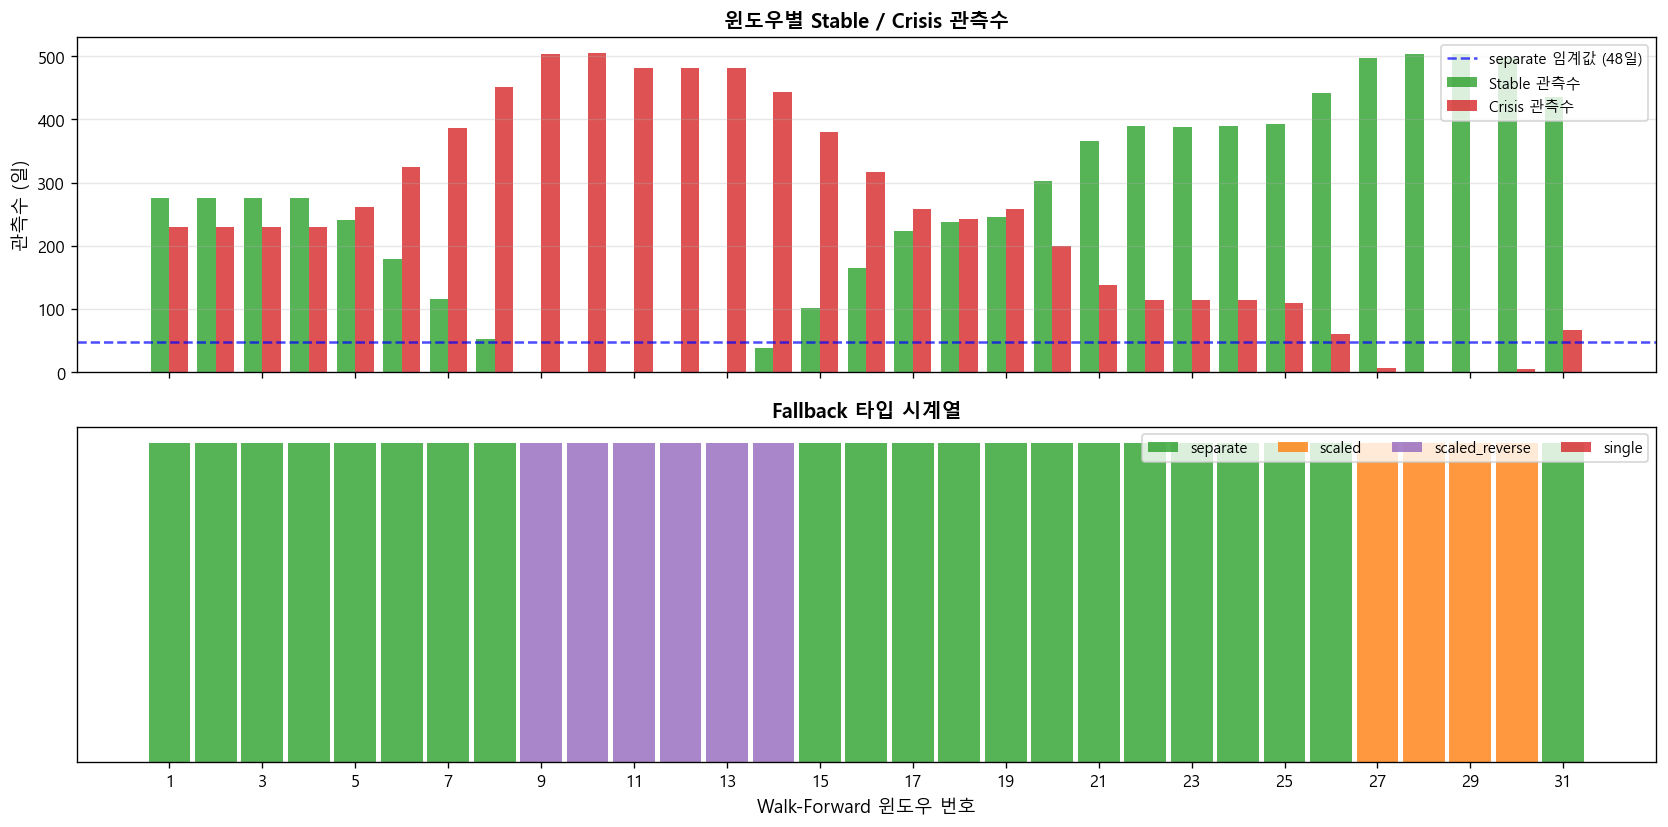

저장: images/step8_02_fallback_log.png


In [9]:
# ============================================================
# Fallback 타입 분포 시각화
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ---- 상단: 윈도우별 Stable/Crisis 관측수 ----
ax1 = axes[0]
x = np.arange(1, len(fallback_log) + 1)
ax1.bar(x - 0.2, fallback_df['n_stable'], width=0.4,
        label='Stable 관측수', color='#2ca02c', alpha=0.8)
ax1.bar(x + 0.2, fallback_df['n_crisis'], width=0.4,
        label='Crisis 관측수', color='#d62728', alpha=0.8)
ax1.axhline(MIN_SEPARATE, color='blue', linestyle='--', alpha=0.7,
            label=f'separate 임계값 ({MIN_SEPARATE}일)')
ax1.set_ylabel('관측수 (일)', fontsize=11)
ax1.set_title('윈도우별 Stable / Crisis 관측수', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ---- 하단: Fallback 타입 색상 바 ----
ax2 = axes[1]
fb_colors = {'separate': '#2ca02c', 'scaled': '#ff7f0e',
             'scaled_reverse': '#9467bd', 'single': '#d62728'}
for xi, fb in zip(x, fallback_df['fallback']):
    ax2.bar(xi, 1, color=fb_colors.get(fb, 'gray'), width=0.9, alpha=0.8)

ax2.set_yticks([])
ax2.set_xlabel('Walk-Forward 윈도우 번호', fontsize=11)
ax2.set_title('Fallback 타입 시계열', fontsize=12, fontweight='bold')
ax2.set_xticks(x[::2])

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.8, label=fb)
                   for fb, c in fb_colors.items()]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=4)

plt.tight_layout()
fig.savefig(IMG_DIR / 'step8_02_fallback_log.png', bbox_inches='tight')
plt.show()
print('저장: images/step8_02_fallback_log.png')


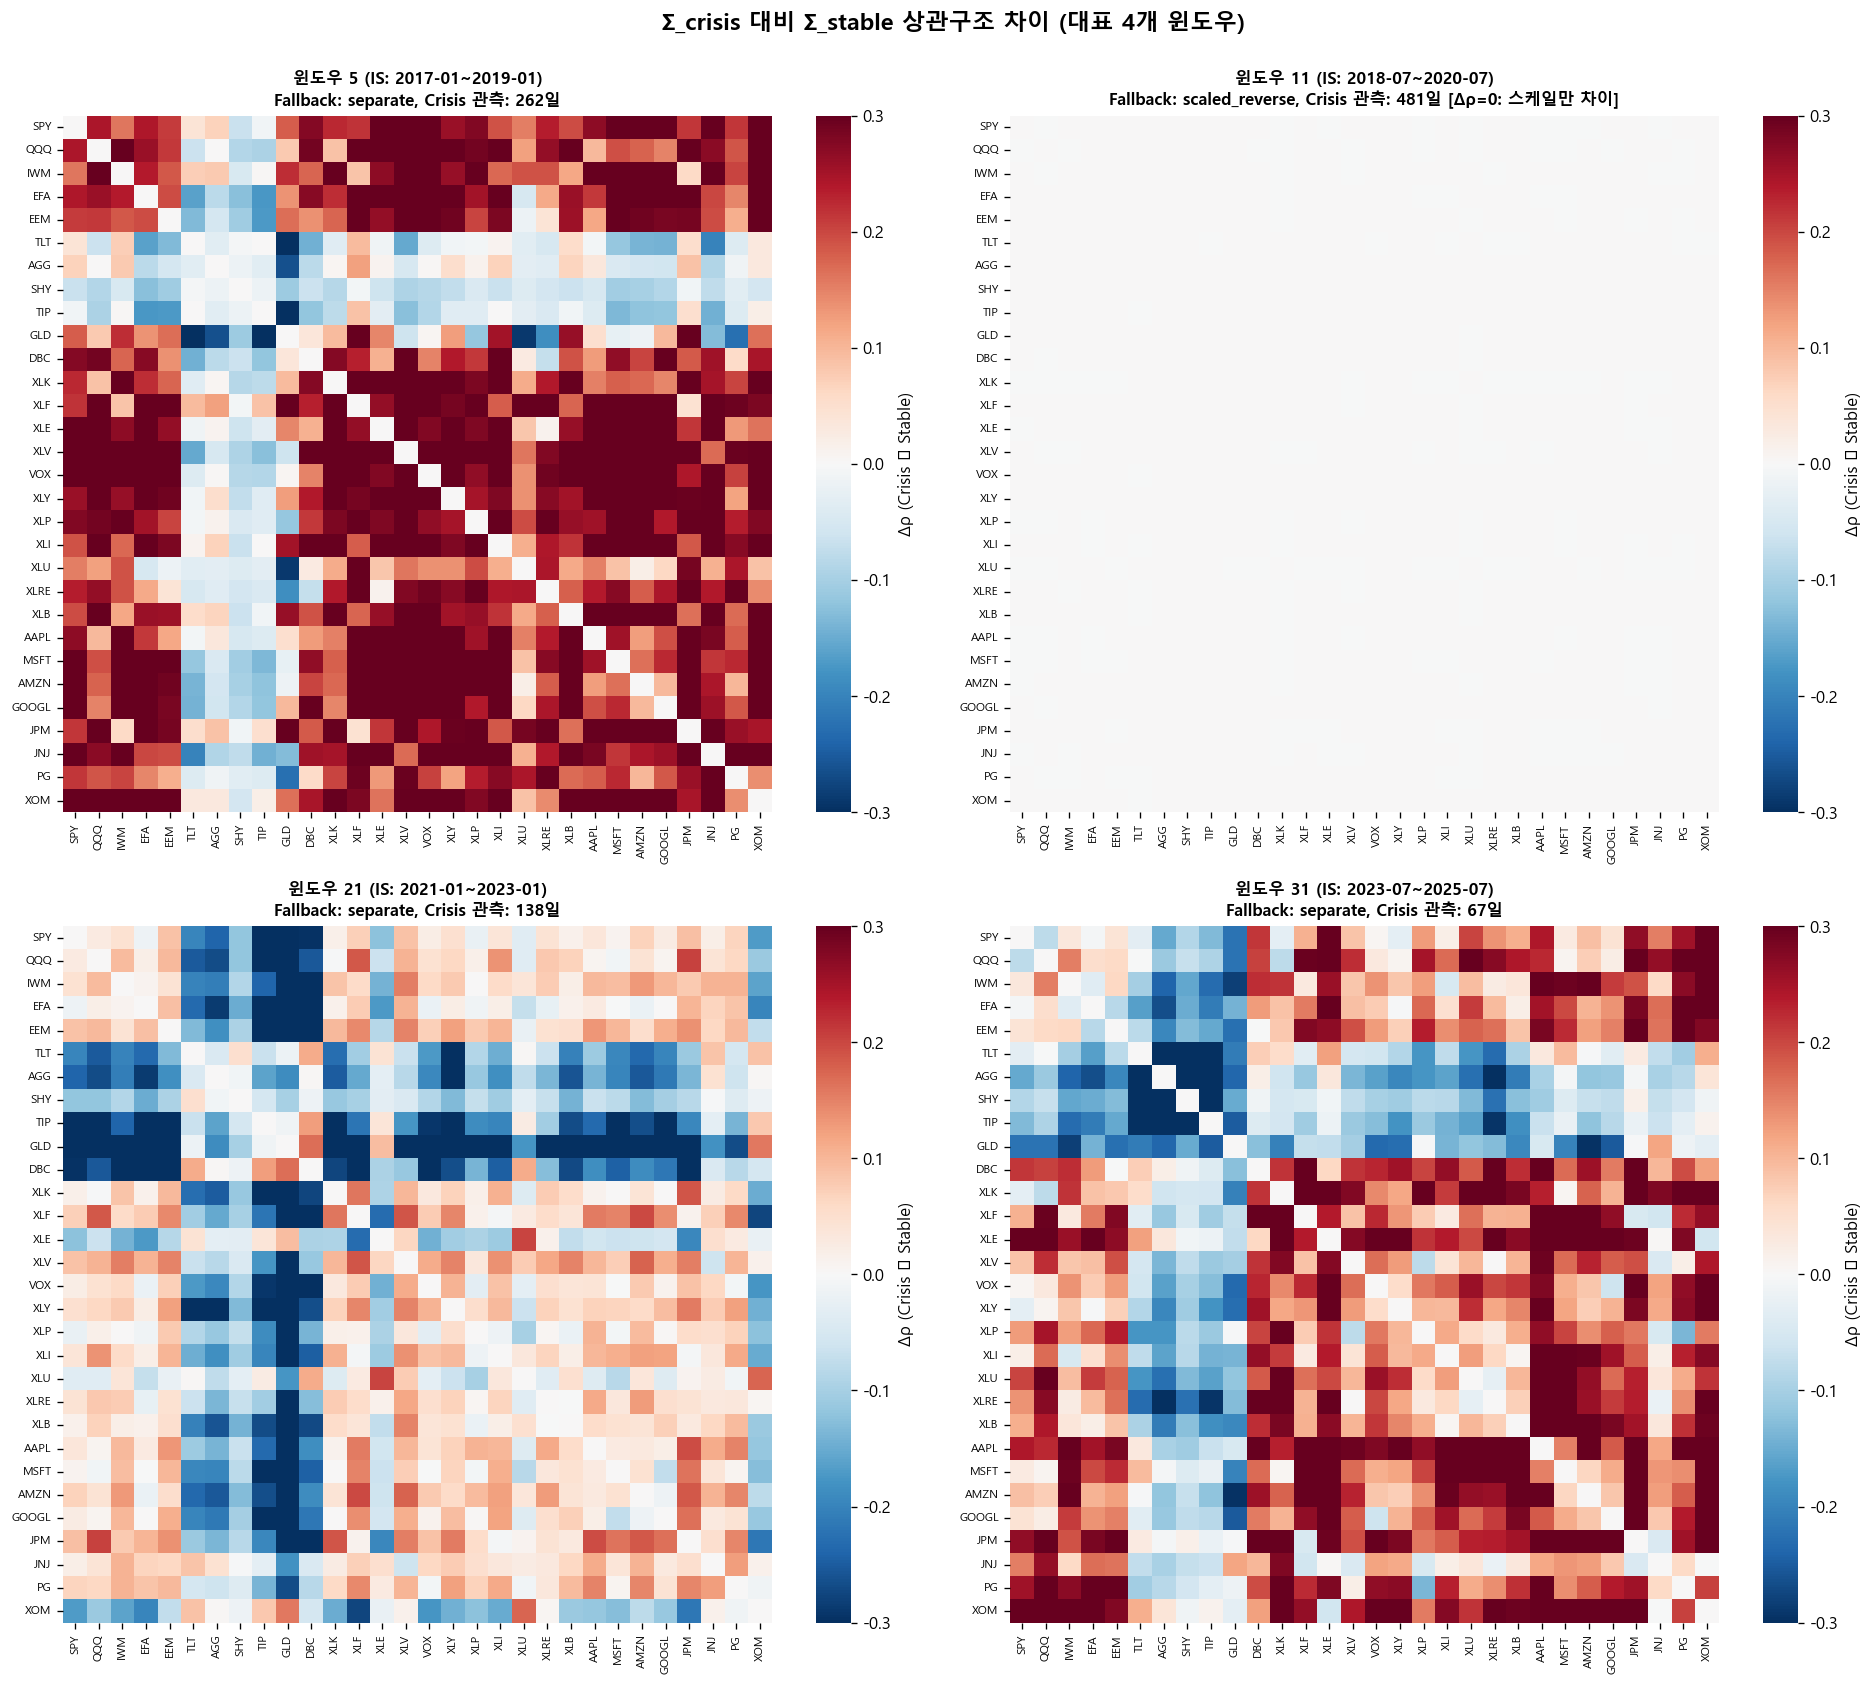

저장: images/step8_03_cov_diff.png


In [10]:
# ============================================================
# Σ_stable vs Σ_crisis 차이 히트맵 (대표 윈도우 4개 선택)
# ============================================================

# 대표 윈도우 선정: 동적으로 n_windows 기반 (초반/1분위/2분위/마지막)
n_windows = len(regime_cov_by_window)
representative_windows = [
    min(4, n_windows - 1),       # 초반 (separate 시작 예상)
    n_windows // 3,              # 1/3 지점
    2 * n_windows // 3,          # 2/3 지점
    n_windows - 1,               # 마지막
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, w_id in enumerate(representative_windows):
    result = regime_cov_by_window[w_id]
    ax = axes[idx]

    # 상관계수로 변환하여 시각화 (스케일 통일)
    std_s = np.sqrt(np.diag(result['Sigma_stable']))
    std_c = np.sqrt(np.diag(result['Sigma_crisis']))

    corr_s = result['Sigma_stable'] / np.outer(std_s, std_s)
    corr_c = result['Sigma_crisis'] / np.outer(std_c, std_c)

    # 차이: Crisis - Stable
    corr_diff = corr_c - corr_s

    # 대각 원소는 항상 0 (상관계수 1로 동일)
    np.fill_diagonal(corr_diff, 0)

    sns.heatmap(corr_diff, ax=ax, cmap='RdBu_r', center=0,
                xticklabels=PORT_TICKERS, yticklabels=PORT_TICKERS,
                vmin=-0.3, vmax=0.3, cbar_kws={'label': 'Δρ (Crisis − Stable)'})

    is_period = f"{result['is_start'].strftime('%Y-%m')}~{result['is_end'].strftime('%Y-%m')}"
    fb = result["fallback_type"]
    # scaled / scaled_reverse는 Σ가 스칼라 배이므로 상관행렬 동일 → Δρ 전부 0
    fb_note = ' [Δρ=0: 스케일만 차이]' if fb.startswith('scaled') else ''
    ax.set_title(f'윈도우 {w_id+1} (IS: {is_period})\n'
                 f'Fallback: {fb}, '
                 f'Crisis 관측: {result["n_crisis"]}일{fb_note}',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

fig.suptitle('Σ_crisis 대비 Σ_stable 상관구조 차이 (대표 4개 윈도우)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig.savefig(IMG_DIR / 'step8_03_cov_diff.png', bbox_inches='tight')
plt.show()
print('저장: images/step8_03_cov_diff.png')


## 8-5. (확장) 4개 Σ 별도 추정 버전

사용자 제안의 대안으로, **4개 레짐 각각에 대해 별도 Σ**를 추정하는 버전도 병행 생성합니다. Step10에서 "2그룹 vs 4그룹" 성과를 비교하여 더 정교한 공분산 구조의 실효성을 검증합니다.

**한계**: 레짐별 관측수가 적으면 추정 불안정. Fallback을 개별 레짐 단위로 확장 적용.


In [11]:
# ============================================================
# 4개 Σ 별도 추정 (확장 실험용)
# ============================================================

MIN_4GROUP_EST = 20  # 4-group 버전: 최소 20일부터 독립 추정 시도


def estimate_4regime_cov(is_returns, is_regimes, all_regimes=[0, 1, 2, 3]):
    """
    4개 레짐 각각에 대해 별도 Σ 추정 (확장 실험용).
    - n_r >= 48일: 'separate' (독립 추정, 충분한 샘플)
    - 20 <= n_r < 48일: 'limited' (독립 추정 시도, Ledoit-Wolf 수축 의존)
    - n_r < 20일: 'single_fallback' (전체 Σ로 대체)
    """
    mu = is_returns.mean().values * 252
    Sigma_by_regime = {}
    fallback_info = {}

    # 백업용 전체 Σ
    Sigma_all = LedoitWolf().fit(is_returns.values).covariance_ * 252

    for r in all_regimes:
        mask = is_regimes == r
        n_r = int(mask.sum())

        if n_r >= MIN_4GROUP_EST:
            returns_r = is_returns[mask]
            Sigma_r = LedoitWolf().fit(returns_r.values).covariance_ * 252
            fallback_info[r] = 'separate' if n_r >= MIN_SEPARATE else 'limited'
        else:
            Sigma_r = Sigma_all
            fallback_info[r] = 'single_fallback'

        Sigma_by_regime[r] = Sigma_r

    return {
        'mu': mu,
        'Sigma_by_regime': Sigma_by_regime,
        'fallback_info': fallback_info,
    }


# 모든 WF 윈도우에 4그룹 Σ 추정 적용
regime_cov_4group = {}

for i, w in enumerate(windows):
    is_ret = log_returns.loc[w['is_start']:w['is_end']]
    is_regs = regime_df.loc[w['is_start']:w['is_end'], 'hmm_regime']
    common_idx = is_ret.index.intersection(is_regs.index)
    is_ret = is_ret.loc[common_idx]
    is_regs = is_regs.loc[common_idx]

    result = estimate_4regime_cov(is_ret, is_regs)
    result['window_id'] = i
    result['is_start']  = w['is_start']
    result['is_end']    = w['is_end']
    result['oos_start'] = w['oos_start']
    result['oos_end']   = w['oos_end']
    result['tickers']   = PORT_TICKERS

    regime_cov_4group[i] = result

# 각 레짐별 fallback 분포 요약
print('=' * 60)
print('4그룹 버전: 레짐별 Fallback 분포')
print('=' * 60)
regime_fallback_summary = {r: {'separate': 0, 'limited': 0, 'single_fallback': 0}
                            for r in [0, 1, 2, 3]}
for i, result in regime_cov_4group.items():
    for r, fb in result['fallback_info'].items():
        regime_fallback_summary[r][fb] += 1

for r in [0, 1, 2, 3]:
    info = regime_fallback_summary[r]
    print(f'  레짐 {r}: separate {info["separate"]}, '
          f'limited {info["limited"]}, single {info["single_fallback"]}')


4그룹 버전: 레짐별 Fallback 분포
  레짐 0: separate 18, limited 1, single 12
  레짐 1: separate 12, limited 0, single 19
  레짐 2: separate 26, limited 0, single 5
  레짐 3: separate 13, limited 2, single 16


## 8-6. 산출물 저장

Step9 통합 백테스트에서 사용할 pickle 파일 2종을 저장합니다.


In [12]:
# ============================================================
# Pickle 산출물 저장
# ============================================================

# 메인 산출물: 2그룹 Σ (Step9 기본 입력)
with open(DATA_DIR / 'regime_covariance_by_window.pkl', 'wb') as f:
    pickle.dump({
        'windows': regime_cov_by_window,
        'stable_regimes': STABLE_REGIMES,
        'crisis_regimes': CRISIS_REGIMES,
        'tickers': PORT_TICKERS,
        'params': {
            'MIN_SEPARATE': MIN_SEPARATE,
            'SCALE_FACTOR': SCALE_FACTOR,
            'is_months': 24,
            'oos_months': 3,
        },
        'fallback_log': fallback_log,
    }, f)

# 확장 산출물: 4그룹 Σ (Step10 실험용)
with open(DATA_DIR / 'regime_covariance_4group.pkl', 'wb') as f:
    pickle.dump({
        'windows': regime_cov_4group,
        'tickers': PORT_TICKERS,
        'regime_fallback_summary': regime_fallback_summary,
    }, f)

# 파일 크기 확인
main_size = os.path.getsize(DATA_DIR / 'regime_covariance_by_window.pkl') / 1024
ext_size = os.path.getsize(DATA_DIR / 'regime_covariance_4group.pkl') / 1024

print('=' * 60)
print('저장 완료')
print('=' * 60)
print(f'  regime_covariance_by_window.pkl : {main_size:7.1f} KB ({len(regime_cov_by_window)}개 윈도우)')
print(f'  regime_covariance_4group.pkl    : {ext_size:7.1f} KB ({len(regime_cov_4group)}개 윈도우)')
print()
print('Step 8 완료. Step 9에서 다음 정보 활용 가능:')
print('  - 32개 윈도우 각각의 μ, Σ_stable, Σ_crisis')
print('  - Fallback 타입별 처리 기록 (fallback_log)')
print('  - 4그룹 Σ 확장 버전 (Step10 비교용)')


저장 완료
  regime_covariance_by_window.pkl :   452.9 KB (31개 윈도우)
  regime_covariance_4group.pkl    :   726.9 KB (31개 윈도우)

Step 8 완료. Step 9에서 다음 정보 활용 가능:
  - 32개 윈도우 각각의 μ, Σ_stable, Σ_crisis
  - Fallback 타입별 처리 기록 (fallback_log)
  - 4그룹 Σ 확장 버전 (Step10 비교용)
